In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
titanic= sns.load_dataset("titanic")

In [10]:
titanic.head()
titanic.info()
titanic.isnull().sum()
  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [19]:
#  fill up the missing value
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[['age']]= imp_median.fit_transform(titanic[['age']])

imp_freq= SimpleImputer(strategy="most_frequent")
titanic[['embarked']]=imp_freq.fit_transform(titanic[['embarked']])


In [18]:
titanic.isnull().sum()
titanic.shape

(891, 15)

In [22]:
# encode
# label encoding for sex feature  
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked']=le.fit_transform(titanic['embarked'])


In [28]:
 #  select the features we want to Use
features=["pclass","sex","fare","embarked","age"]
target=['survived']


X=titanic[features]
y=titanic[target]

In [29]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [30]:
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [32]:
# Build A Decision Tree Simple model without pruning
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier() # no pruning

model.fit(X_train,y_train)
 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
print(f"Accuracy for our model : {accuracy_score(y_test,y_pred)}")


Accuracy for our model : 0.7653631284916201


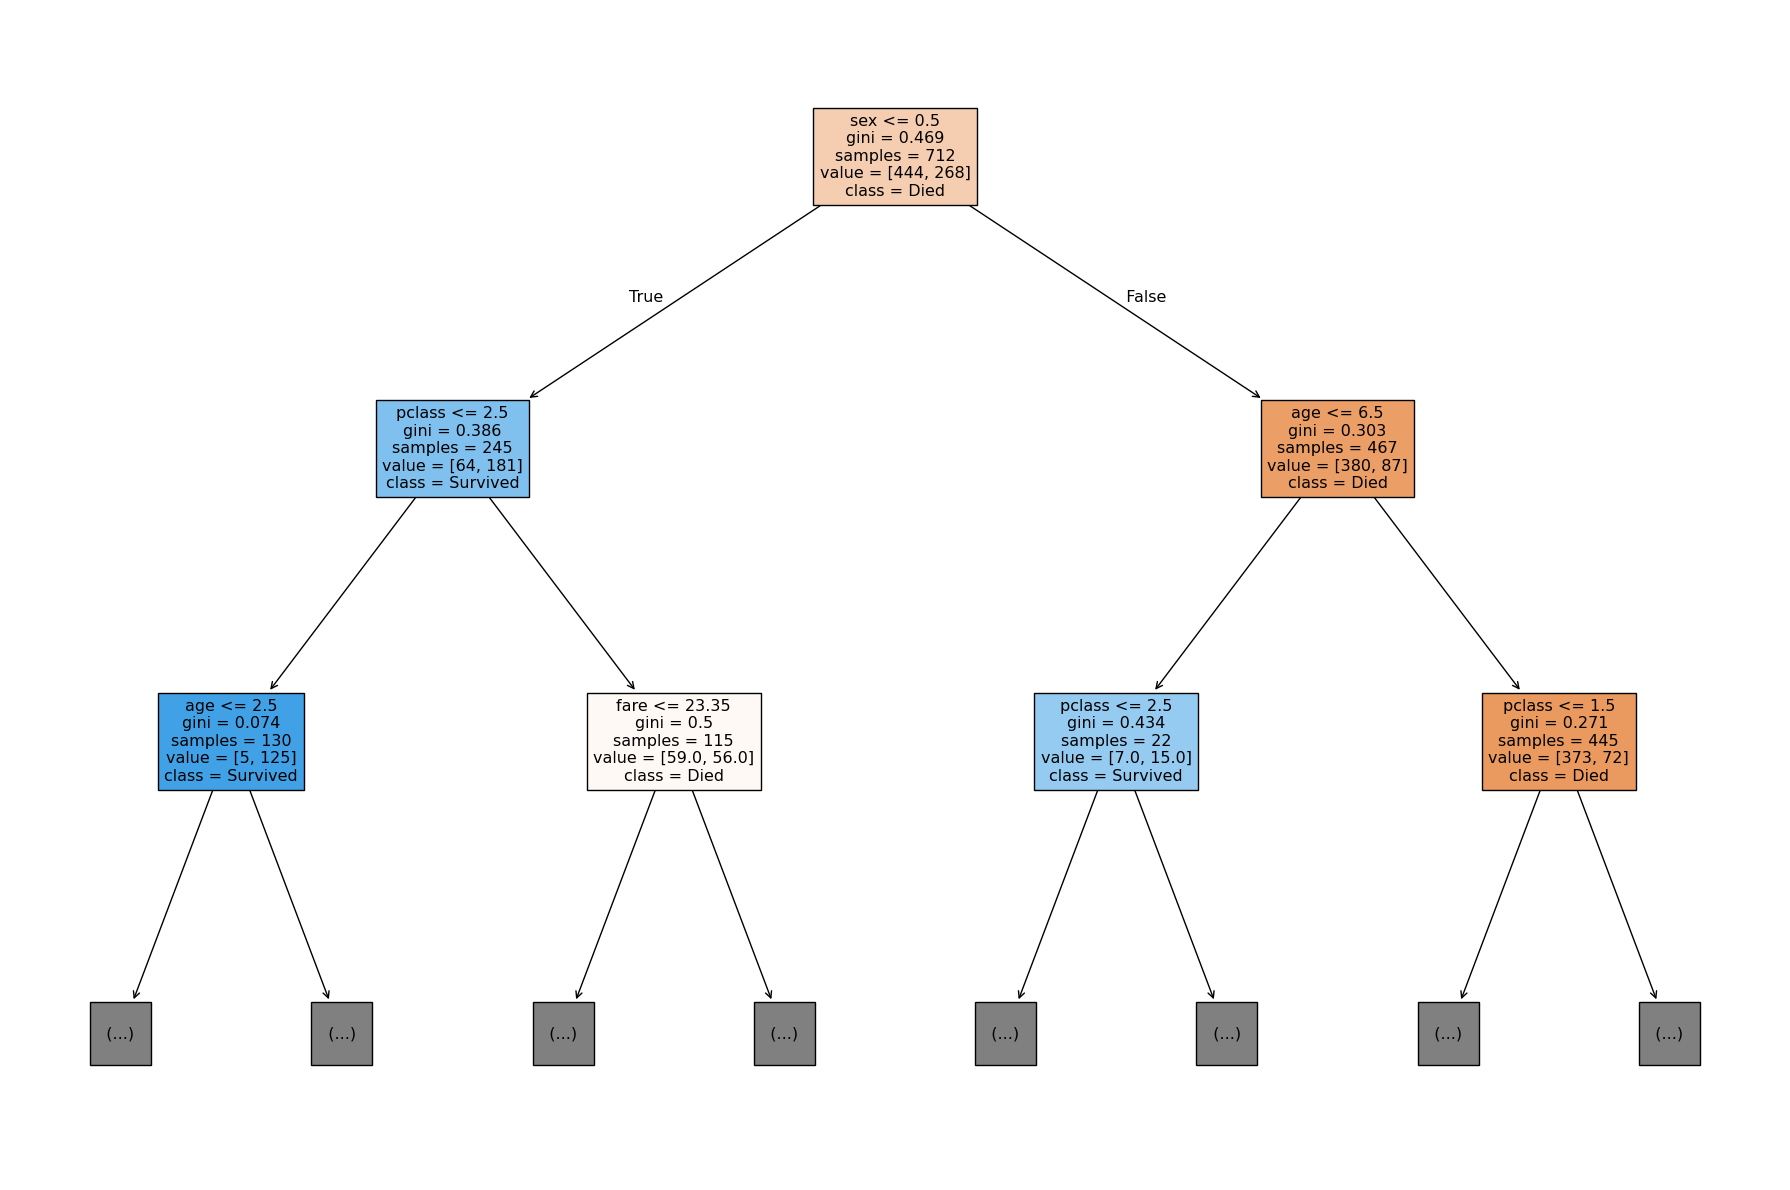

In [39]:
 # plot tree 
from sklearn.tree import plot_tree

plt.figure(figsize=(18,12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names= ["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()
